# Projeto Individual de Visão por Computador

## Motivação
O dataset excolhido foi o [CelebFaces Attributes (CelebA)](https://www.kaggle.com/datasets/jessicali9530/celeba-dataset) um dataset de imagens de rostos humanos onde são categorizados com 40 feições diferentes como "ter barba", "ser homem" ou "cor do cabelo" onde cada imagem pode se encaixar em mais de uma categoria.

A escolha do data set foi feita inspirado no [notebook 13 CVAE apresentado nas aulas](https://github.com/Nau3D/Deep-Learning-Course-PyTorch/blob/master/13-CVAE.ipynb) onde o objetivo além de explorar o conceito de Auto Encoders gostaria de buscar explorar os clusters e a geração de imagens quando pedimos com diferentes categorias, durante as aulas o dataset MNIST poderia ser usado para gerar imagens expecificando a categoria, o objetivo que gostaria de alcança seria gerar imagens expecificando mais de uma categoria, inclusive observar o comportamento da CNN ao pedir categorias contraditorias como uma pessoa careca e com um estilo de cabelo

## Estratégia

### Arquitetura: porquê um CVAE em vez de um GAN
Foi escolhido um **Conditional Variational Autoencoder (CVAE)** em vez de um GAN porque o objetivo principal não era apenas gerar imagens realistas, mas sim ter **controlo explícito sobre os atributos gerados**. Num VAE condicional, o vetor de atributos é injetado tanto no encoder como no decoder, o que permite:
- gerar imagens especificando diretamente que atributos a face deve ter (ex.: `Male=1, Smiling=1, Eyeglasses=1`);
- combinar atributos que normalmente não coexistem nas imagens reais (ex.: `Bald=1` com `Wavy_Hair=1`), testando como a rede interpola entre conceitos que nunca viu juntos no dataset;
- interpolar suavemente entre dois conjuntos de atributos diferentes (ver secção de Interpolação), algo mais difícil de controlar num GAN não condicional.

A condicionalidade é feita projetando o vetor de 40 atributos para um mapa 8×8 que é depois upsampled e concatenado à imagem de entrada no encoder (`attr_embed`), e concatenado diretamente ao vetor latente `z` no decoder.

### Exploração da função de erro
Esta foi a componente central do trabalho, na linha do que é feito em arquiteturas como a Pix2Pix (que combina uma loss adversarial com uma loss L1 para forçar tanto realismo como fidelidade pixel-a-pixel). Aqui a loss total é composta por **três termos**:

1. **Reconstrução L1** — `F.l1_loss(x_hat, x)`. Foi escolhida L1 em vez de MSE porque penaliza menos os outliers e tende a preservar melhor arestas/contornos, reduzindo o efeito de "borrão" (blur) característico de VAEs treinados apenas com MSE.

2. **Divergência KL** — regulariza o espaço latente para se aproximar de uma distribuição normal, ponderada por um hiperparâmetro `BETA`. Foi reduzido de `BETA=0.5` para `BETA=0.1` ao longo das experiências: um β mais baixo dá menos peso à regularização e mais à qualidade da reconstrução, à custa de um espaço latente menos "suave" (amostragem aleatória de `z` produz resultados menos consistentes, mas a reconstrução condicionada em atributos fica mais nítida).

3. **Perceptual Loss (VGG16)** — adicionada numa segunda fase de experimentação. Em vez de comparar pixels diretamente, esta loss passa a imagem real e a reconstruída por uma rede VGG16 pré-treinada (congelada, sem gradientes) e compara as suas representações internas (`features[:16]`). Isto penaliza diferenças percetuais (textura, estrutura) em vez de diferenças pixel-a-pixel, o que é a principal causa documentada de blurriness em VAEs — o erro L1/MSE puro incentiva a rede a "tirar a média" de várias soluções plausíveis, resultando em imagens suaves; a perceptual loss não tem este problema porque compara espaços de features de alto nível.

A loss final é:
```
loss = recon_L1 + BETA * KL + perc_weight * perceptual_loss
```
com `perc_weight = 10.0` para equilibrar a escala dos diferentes termos (a perceptual loss tem magnitude muito menor que a soma L1, por isso precisa de um peso maior para ter impacto comparável no gradiente).

### Manipulação do dataset
Em vez de usar o dataset CelebA "tal como está", a estratégia explora a **combinação dos 40 atributos como espaço de manipulação**:
- a função `make_condition` permite construir qualquer combinação de atributos (incluindo combinações ausentes ou raras no dataset original);
- a função `interpolate_attrs` faz uma interpolação linear entre dois vetores de atributos diferentes, gerando uma sequência de imagens que mostra a transição suave entre dois "perfis" de atributos (ex.: de uma pessoa jovem sorridente para um homem com barba).

### Hiperparâmetros principais
| Parâmetro | Valor | Justificação |
|---|---|---|
| `IMG_SIZE` | 128 | compromisso entre detalhe e tempo de treino em GPU gratuita (Kaggle T4) |
| `LATENT_DIM` | 512 | aumentado de 256 para dar mais capacidade ao espaço latente de codificar detalhe facial |
| `BETA` | 0.1 | reduzido para priorizar nitidez da reconstrução sobre suavidade do espaço latente |
| `perc_weight` | 10.0 | escala a perceptual loss para ter peso comparável à reconstrução L1 |
| Scheduler | CosineAnnealingLR | decaimento suave da learning rate ao longo das 300 épocas, evitando os degraus abruptos do `ReduceLROnPlateau` |

### Resultados e discussão
*(completar após o treino: incluir aqui exemplos visuais comparando reconstruções com e sem perceptual loss, e a curva de loss de treino/validação. Sugestão: usar `history['loss']` e `history['val_loss']` guardados no checkpoint para o gráfico, e gerar imagens com os mesmos atributos usando o checkpoint antigo (`_best.pt` sem perceptual loss) vs. o novo, para uma comparação direta.)*


In [ ]:

import os, torch

DATA_DIR = '/kaggle/input/datasets/jessicali9530/celeba-dataset'
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NOT AVAILABLE — enable in Session options')
print('Dataset contents:', os.listdir(DATA_DIR))

GPU: Tesla T4
Dataset contents: ['list_landmarks_align_celeba.csv', 'img_align_celeba', 'list_eval_partition.csv', 'list_attr_celeba.csv', 'list_bbox_celeba.csv']


In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from PIL import Image
from tqdm import tqdm
import os, multiprocessing

## Config

In [ ]:
IMG_SIZE   = 64
BATCH_SIZE = 128
LATENT_DIM = 256  
NUM_ATTRS  = 40
EPOCHS     = 30
SAVE_EVERY = 50   
BETA       = 0.1  
LR         = 3e-4
TRAIN      = True

# Kaggle paths
DATA_DIR   = '/kaggle/input/datasets/jessicali9530/celeba-dataset'
IMG_DIR    = os.path.join(DATA_DIR, 'img_align_celeba/img_align_celeba')
ATTR_FILE  = os.path.join(DATA_DIR, 'list_attr_celeba.csv')
SPLIT_FILE = os.path.join(DATA_DIR, 'list_eval_partition.csv')
MODEL_PATH = '/kaggle/working/celeba_64.pt'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

ATTR_NAMES = [
    '5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive',    'Bags_Under_Eyes', 'Bald',
    'Bangs',            'Big_Lips',         'Big_Nose',      'Black_Hair',      'Blond_Hair',
    'Blurry',           'Brown_Hair',       'Bushy_Eyebrows','Chubby',          'Double_Chin',
    'Eyeglasses',       'Goatee',           'Gray_Hair',     'Heavy_Makeup',    'High_Cheekbones',
    'Male',             'Mouth_Slightly_Open','Mustache',    'Narrow_Eyes',     'No_Beard',
    'Oval_Face',        'Pale_Skin',        'Pointy_Nose',   'Receding_Hairline','Rosy_Cheeks',
    'Sideburns',        'Smiling',          'Straight_Hair', 'Wavy_Hair',       'Wearing_Earrings',
    'Wearing_Hat',      'Wearing_Lipstick', 'Wearing_Necklace','Wearing_Necktie','Young',
]

Device: cpu


## Dataset

Kaggle's CelebA comes as `.jpg` files + CSV files (not parquet).  
The split CSV uses: `0 = train`, `1 = valid`, `2 = test`.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=transforms.InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])


class CelebAKaggle(Dataset):
    def __init__(self, img_dir, attr_file, split_file, split_id, transform=None):

        self.img_dir   = img_dir
        self.transform = transform

        splits = pd.read_csv(split_file)
        
        if splits.shape[1] == 1:
            splits = pd.read_csv(split_file, sep=' ', header=None, names=['filename', 'split'])
        else:
            splits.columns = ['filename', 'split']

        attrs = pd.read_csv(attr_file)

        attrs = attrs.set_index(attrs.columns[0])
        attrs = attrs.replace(-1, 0)  

        mask         = splits['split'] == split_id
        self.files   = splits[mask]['filename'].values
        self.attrs   = attrs.loc[self.files, ATTR_NAMES].values.astype('float32')

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.img_dir, self.files[idx])).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.from_numpy(self.attrs[idx])


print('Loading datasets...')
train_ds = CelebAKaggle(IMG_DIR, ATTR_FILE, SPLIT_FILE, split_id=0, transform=transform)
valid_ds = CelebAKaggle(IMG_DIR, ATTR_FILE, SPLIT_FILE, split_id=1, transform=transform)

pin = device.type == 'cuda'

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=pin, persistent_workers=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)
print(f'Train: {len(train_ds)} | Valid: {len(valid_ds)}')


imgs, attrs = next(iter(valid_loader))
print(f'Valid batch OK — shape: {imgs.shape}, nan: {imgs.isnan().any().item()}')

## Model

In [4]:
def conv_block(in_ch, out_ch, stride=2):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 4, stride, 1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.LeakyReLU(0.2, inplace=True),
    )

def deconv_block(in_ch, out_ch, act=True):
    layers = [nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False)]
    if act:
        layers += [
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
    return nn.Sequential(*layers)


class Encoder(nn.Module):
    def __init__(self, latent_dim, num_attrs):
        super().__init__()
        self.attr_embed = nn.Linear(num_attrs, 8 * 8)
        self.net = nn.Sequential(
            conv_block(4,   64),
            conv_block(64,  128),
            conv_block(128, 256),
            conv_block(256, 512),
            nn.AdaptiveAvgPool2d(4),
            nn.Flatten(),
        )
        self.fc_mu      = nn.Linear(512*4*4, latent_dim)
        self.fc_log_var = nn.Linear(512*4*4, latent_dim)

    def forward(self, x, attrs):
        a = self.attr_embed(attrs).view(-1, 1, 8, 8)
        a = F.interpolate(a, size=(IMG_SIZE, IMG_SIZE), mode='bilinear', align_corners=False)
        x = torch.cat([x, a], dim=1)
        h = self.net(x)
        return self.fc_mu(h), self.fc_log_var(h)


class Decoder(nn.Module):
    def __init__(self, latent_dim, num_attrs):
        super().__init__()
        self.fc   = nn.Linear(latent_dim + num_attrs, 512*4*4)
        steps     = max(1, IMG_SIZE // 64)
        extra     = nn.Sequential(*[deconv_block(64, 64) for _ in range(steps - 1)])
        self.net  = nn.Sequential(
            deconv_block(512, 256),
            deconv_block(256, 128),
            deconv_block(128, 64),
            extra,
            deconv_block(64, 3, act=False),
            nn.Tanh(),
        )

    def forward(self, z, attrs):
        x = torch.cat([z, attrs], dim=1)
        x = self.fc(x).view(-1, 512, 4, 4)
        return self.net(x)


class CVAE(nn.Module):
    def __init__(self, latent_dim, num_attrs):
        super().__init__()
        self.encoder = Encoder(latent_dim, num_attrs)
        self.decoder = Decoder(latent_dim, num_attrs)

    def reparameterise(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        return mu + std * torch.randn_like(std)

    def forward(self, x, attrs):
        mu, log_var = self.encoder(x, attrs)
        log_var     = log_var.clamp(-10, 4)
        z           = self.reparameterise(mu, log_var)
        return self.decoder(z, attrs), mu, log_var


from torchvision.models import vgg16, VGG16_Weights

class PerceptualLoss(nn.Module):
    
    def __init__(self):
        super().__init__()
        vgg = vgg16(weights=VGG16_Weights.DEFAULT).features[:16].eval()
        for p in vgg.parameters():
            p.requires_grad = False
        self.vgg = vgg
        
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1))
        self.register_buffer('std',  torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1))

    def forward(self, x, x_hat):
        
        x     = (x     * 0.5 + 0.5 - self.mean) / self.std
        x_hat = (x_hat * 0.5 + 0.5 - self.mean) / self.std
        return F.l1_loss(self.vgg(x_hat), self.vgg(x))


def vae_loss(x, x_hat, mu, log_var, beta=1.0, perc_loss=None, perc_weight=1.0):
    
    recon = F.l1_loss(x_hat, x, reduction='mean')
    kl    = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / x.size(0)
    
    kl_norm = kl / (x.size(2) * x.size(3) * x.size(1))
    perc  = perc_loss(x, x_hat) * perc_weight if perc_loss is not None else 0.0
    return recon + beta * kl_norm + perc, recon, kl


model      = CVAE(LATENT_DIM, NUM_ATTRS).to(device)
perceptual = PerceptualLoss().to(device)
optimizer  = torch.optim.Adam(model.parameters(), lr=LR)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)
print(f'{sum(p.numel() for p in model.parameters())/1e6:.1f}M params')

12.9M params


## Train

In [ ]:
if TRAIN:
    
    start_epoch = 0
    best_val    = float('inf')
    history     = {'loss': [], 'val_loss': []}

    if os.path.exists(MODEL_PATH):
        print(f'Checkpoint found — resuming from {MODEL_PATH}')
        ckpt = torch.load(MODEL_PATH, map_location=device)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        start_epoch = ckpt['epoch'] + 1
        best_val    = ckpt['best_val']
        history     = ckpt['history']
        print(f'Resuming from epoch {start_epoch + 1}/{EPOCHS} | best val so far: {best_val:.4f}')
    else:
        print('No checkpoint found — starting from scratch')

    if start_epoch >= EPOCHS:
        print(f'Already trained {EPOCHS} epochs. Increase EPOCHS to continue.')
    else:
        use_amp = device.type == 'cuda'
        scaler  = torch.amp.GradScaler('cuda', enabled=use_amp)

        for epoch in range(start_epoch, EPOCHS):
            model.train()
            running = 0.0
            for imgs, attrs in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}'):
                imgs  = imgs.to(device, non_blocking=True)
                attrs = attrs.to(device, non_blocking=True)

                with torch.autocast(device_type=device.type, enabled=use_amp):
                    out, mu, lv = model(imgs, attrs)
                    loss, _, _  = vae_loss(imgs, out, mu, lv, BETA, perceptual)

                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
                running += loss.item() * imgs.size(0)

            model.eval()
            val_run         = 0.0
            val_n           = 0
            val_nan_batches = 0
            with torch.no_grad():
                for imgs, attrs in valid_loader:
                    imgs  = imgs.to(device)
                    attrs = attrs.to(device)
                    
                    _, mu, lv = model(imgs, attrs)
                    out       = model.decoder(mu, attrs)
                    l, _, _   = vae_loss(imgs, out, mu, lv, BETA)
                    if l.isnan():
                        val_nan_batches += 1
                    else:
                        val_run += l.item() * imgs.size(0)
                        val_n   += imgs.size(0)

            tl = running / len(train_ds)
            vl = val_run / val_n if val_n > 0 else float('nan')
            scheduler.step()
            history['loss'].append(tl)
            history['val_loss'].append(vl)
            nan_note = f' | val_nan_batches {val_nan_batches}' if val_nan_batches else ''
            print(f'Epoch {epoch+1:03d} | loss {tl:.4f} | val {vl:.4f}{nan_note}')

            ckpt_data = {
                'model':     model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict(),
                'epoch':     epoch,
                'best_val':  best_val,
                'history':   history,
            }

            torch.save(ckpt_data, MODEL_PATH)

            if (epoch + 1) % SAVE_EVERY == 0:
                snap_path = MODEL_PATH.replace('.pt', f'_epoch{epoch+1:03d}.pt')
                torch.save(ckpt_data, snap_path)
                print(f'  snapshot saved → {snap_path}')

            if vl < best_val:
                best_val = vl
                ckpt_data['best_val'] = best_val
                torch.save(ckpt_data, MODEL_PATH.replace('.pt', '_best.pt'))
                print(f'  saved best (val {vl:.4f})')

        print(f'Done. Best val loss: {best_val:.4f}')

        plt.figure(figsize=(8, 4))
        plt.plot(history['loss'],     label='train')
        plt.plot(history['val_loss'], label='val')
        plt.xlabel('Epoch'); plt.ylabel('Loss')
        plt.title('Training history'); plt.legend()
        plt.tight_layout(); plt.show()

Checkpoint found — resuming from /kaggle/working/celeba_64.pt
Resuming from epoch 18/150 | best val so far: 0.0942


Epoch 18/150: 100%|██████████| 1272/1272 [02:04<00:00, 10.24it/s]


Epoch 018 | loss 1.0629 | val 0.0938
  saved best (val 0.0938)


Epoch 19/150: 100%|██████████| 1272/1272 [02:04<00:00, 10.20it/s]


Epoch 019 | loss 1.0590 | val 0.0941


...

Epoch 47/150: 100%|██████████| 1272/1272 [02:04<00:00, 10.21it/s]


Epoch 047 | loss 1.0009 | val 0.0917


Epoch 48/150: 100%|██████████| 1272/1272 [02:04<00:00, 10.22it/s]


Epoch 048 | loss 0.9990 | val 0.0919


Epoch 49/150:  66%|██████▌   | 834/1272 [01:21<00:42, 10.39it/s]

In [ ]:
model.eval()
imgs, attrs = next(iter(valid_loader))
imgs, attrs = imgs.to(device), attrs.to(device)

with torch.no_grad():
    out, mu, lv = model(imgs, attrs)
    recon = F.l1_loss(out, imgs, reduction='mean')          # now mean, same as training
    kl    = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp()) / imgs.size(0)
    kl_norm = kl / (imgs.size(2) * imgs.size(3) * imgs.size(1))
    perc  = perceptual(imgs, out)

print(f'recon (mean)       = {recon.item():.4f}  (target: < 0.15 for decent quality)')
print(f'kl (raw/dim)       = {kl.item():.1f}   | kl_norm = {kl_norm.item():.4f}')
print(f'kl_norm * BETA     = {kl_norm.item()*BETA:.4f}')
print(f'perceptual (raw)   = {perc.item():.4f}')
print(f'total loss ~=      {recon.item() + kl_norm.item()*BETA + perc.item():.4f}')
print()
print(f'recon : perceptual ratio = {recon.item() / max(perc.item(), 1e-8):.1f}  (ideal: 0.5–2.0)')


In [7]:
ckpt = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(ckpt['model'])
model.eval()
print('Loaded epoch', ckpt['epoch'])

Loaded epoch 43


In [8]:
import math

def make_condition(attr_dict, n_samples=8):
    
    cond = torch.zeros(NUM_ATTRS)
    invalid = [k for k in attr_dict if k not in ATTR_NAMES]
    if invalid:
        raise ValueError(f"Unknown attribute(s): {invalid}\nValid: {ATTR_NAMES}")
    for name, val in attr_dict.items():
        cond[ATTR_NAMES.index(name)] = float(val)
    return cond.unsqueeze(0).expand(n_samples, -1).to(device)


def generate(
    attr_dict,
    n_samples: int = 8,
    temperature: float = 1.0,
    cols: int | None = None,
    figsize_per_img: tuple[float, float] = (2.0, 2.2),
    save_path: str | None = None,
    seed: int | None = None,
    return_imgs: bool = False,
    title_fontsize: int = 9,
):

    if seed is not None:
        torch.manual_seed(seed)

    cond = make_condition(attr_dict, n_samples)
    with torch.no_grad():
        z    = torch.randn(n_samples, LATENT_DIM, device=device) * temperature
        imgs = model.decoder(z, cond)
    imgs = (imgs.cpu() * 0.5 + 0.5).clamp(0, 1)  

    if cols is None:
        cols = min(n_samples, 8)
    rows = math.ceil(n_samples / cols)

    fw = figsize_per_img[0] * cols
    fh = figsize_per_img[1] * rows + 0.5      # +0.5 for suptitle
    fig, axes = plt.subplots(rows, cols, figsize=(fw, fh),
                             squeeze=False)

    title = ', '.join(
        f'{k}={("✓" if v else "✗")}' for k, v in attr_dict.items()
    )
    fig.suptitle(title, fontsize=title_fontsize, y=1.01)

    imgs_np = imgs.permute(0, 2, 3, 1).numpy()   

    for idx, ax in enumerate(axes.flat):
        if idx < n_samples:
            ax.imshow(imgs_np[idx])
        ax.axis('off')

    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
        print(f"Saved → {save_path}")

    plt.show()
    plt.close(fig)

    if return_imgs:
        return (imgs_np * 255).astype(np.uint8)


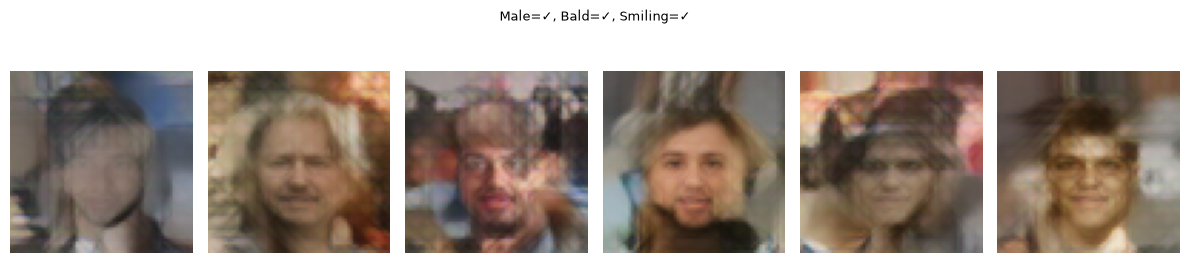

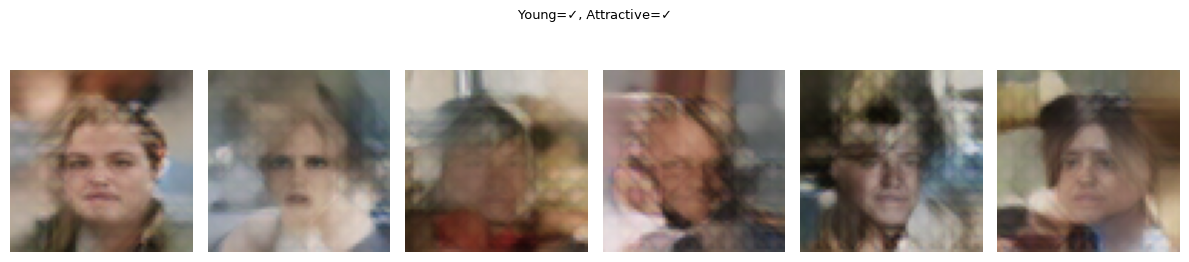

In [9]:
# Reproducible grid, saved to file
generate(
    {'Male': 1, 'Bald': 1, 'Smiling': 1},
    n_samples=6,
    seed=42,
)

# Get images back as numpy for downstream use
generate({'Young': 1, 'Attractive': 1}, n_samples=6)